In [199]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plot

In [200]:
df=pd.read_csv("tech_job_market_2019_2026.csv")
df.head()

,job_id,company_name,company_type,sector,company_size_employees,hq_country,job_role,seniority_level,years_experience_min,years_experience_max,required_tech_stack,primary_programming_language,work_mode,visa_sponsorship_offered,job_location_country,job_location_city,salary_currency,posting_date,application_deadline,date_position_filled,position_status,number_of_applicants,number_of_interview_rounds,offers_extended,offers_accepted,salary_min_usd,salary_max_usd,layoff_within_12_months_flag
0,JOB041385,CobaltWealth,MNC,HealthTech,146085,Germany,SOC Analyst,Mid,3,5,"AWS Security Hub, Burp Suite, Splunk",Go,Hybrid,N,Germany,Munich,EUR,2023-09-21,2023-11-12 00:00:00,2023-11-20,Filled,98.0,4.0,5.0,5.0,-1,-1,N
1,JOB018462,DriftLearn,Mid-size,Cloud/Infra,5882,USA,Mobile Engineer (iOS),Mid,1,4,"C++, TypeScript, Python, Kotlin",Python,Remote,No,USA,NaN,USD,2025-05-11,2025-06-29 00:00:00,NaN,Open,134.0,2.0,1.0,0.0,NaN,NaN,No
2,JOB110011,AnchorBuzz Labs,MNC,HealthTech,186507,USA,QA Engineer,Lead,7,15,"Swift, C++, Kotlin, Python",Go,Hybrid,Y,USA,San Francisco,USD,2025-12-01,2026-01-24 00:00:00,2026-02-08,Filled,36.0,4.0,1.0,1.0,238800.0,274700.0,0
3,JOB073462,KiteSphere,Unicorn,HealthTech,10930,Brazil,Research Scientist,Entry,1,4,"dbt, Spark, Python, Snowflake, Airflow",R,Onsite,0,Germany,Frankfurt,EUR,2020-11-21,2020-12-09 00:00:00,2020-12-21,Filled,300.0,1.0,6.0,5.0,96300.0,104000.0,Yes
4,JOB051683,AetherNode Co,MNC,Social/AdTech,42510,USA,Product Manager,Senior,6,9,"Amplitude, Jira, SQL, Notion, Figma",NaN,Hybrid,N,India,Pune,INR,2025-07-03,2025-07-19 00:00:00,2025-09-15,Filled,43.0,3.0,1.0,1.0,"$186,800",245400.0,1


In [201]:
df.shape

(115000, 28)

In [202]:
df.describe()

,company_size_employees,years_experience_min,years_experience_max,number_of_applicants,number_of_interview_rounds,offers_extended,offers_accepted
count,115000.000000,115000.000000,115000.000000,113890.000000,114564.000000,114670.000000,114670.000000
mean,105386.103122,3.004452,6.665443,181.659215,3.307653,1.349786,1.196634
std,102117.290040,3.093383,5.073654,436.344753,1.418283,1.457267,1.122837
min,10.000000,0.000000,0.000000,-5.000000,1.000000,0.000000,0.000000
25%,6038.750000,1.000000,3.000000,62.000000,2.000000,1.000000,1.000000
50%,88364.000000,2.000000,6.000000,119.000000,3.000000,1.000000,1.000000
75%,169840.250000,5.000000,9.000000,213.000000,4.000000,1.000000,1.000000
max,488674.000000,24.000000,24.000000,36816.000000,8.000000,8.000000,10.000000


In [203]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 115000 entries, 0 to 114999
Data columns (total 28 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   job_id                        115000 non-null  str    
 1   company_name                  115000 non-null  str    
 2   company_type                  115000 non-null  str    
 3   sector                        115000 non-null  str    
 4   company_size_employees        115000 non-null  int64  
 5   hq_country                    115000 non-null  str    
 6   job_role                      115000 non-null  str    
 7   seniority_level               115000 non-null  str    
 8   years_experience_min          115000 non-null  int64  
 9   years_experience_max          115000 non-null  int64  
 10  required_tech_stack           115000 non-null  str    
 11  primary_programming_language  92525 non-null   str    
 12  work_mode                     115000 non-null  str    


float datatype=4
int datatype=3
string datatype =21

In [204]:
df.isnull().sum()

job_id                              0
company_name                        0
company_type                        0
sector                              0
company_size_employees              0
hq_country                          0
job_role                            0
seniority_level                     0
years_experience_min                0
years_experience_max                0
required_tech_stack                 0
primary_programming_language    22475
work_mode                           0
visa_sponsorship_offered            0
job_location_country                0
job_location_city               25107
salary_currency                     0
posting_date                        0
application_deadline             5757
date_position_filled            25781
position_status                     0
number_of_applicants             1110
number_of_interview_rounds        436
offers_extended                   330
offers_accepted                   330
salary_min_usd                   3318
salary_max_u

# conclusions
- there are missing values in columns,but they are very few to be dropped

In [205]:
df.duplicated().sum()

np.int64(1193)

In [206]:
print(df[df.duplicated()])

           job_id  ... layoff_within_12_months_flag
1584    JOB002656  ...                        False
2216    JOB000563  ...                            1
2969    JOB073226  ...                           No
3897    JOB022039  ...                            N
4327    JOB006733  ...                            N
4856    JOB080730  ...                        False
5396    JOB004089  ...                        False
5565    JOB044222  ...                          Yes
5987    JOB088013  ...                            0
6178    JOB018700  ...                            0
6181    JOB003467  ...                            0
6311    JOB020909  ...                            0
7310    JOB013848  ...                        False
7362    JOB050601  ...                            0
7392    JOB061798  ...                           No
7465    JOB037507  ...                            0
7570    JOB002570  ...                           No
7709    JOB005262  ...                           No
7758    JOB0

In [207]:
df.drop_duplicates(inplace=True)

In [208]:
df.duplicated().sum()

np.int64(0)

In [209]:
df.describe()   

,company_size_employees,years_experience_min,years_experience_max,number_of_applicants,number_of_interview_rounds,offers_extended,offers_accepted
count,113807.000000,113807.000000,113807.000000,112704.000000,113373.000000,113479.000000,113479.000000
mean,105407.621552,3.004174,6.664124,181.779112,3.307525,1.349298,1.196415
std,102128.678701,3.092817,5.072197,437.798085,1.418054,1.456431,1.122430
min,10.000000,0.000000,0.000000,-5.000000,1.000000,0.000000,0.000000
25%,6044.500000,1.000000,3.000000,62.000000,2.000000,1.000000,1.000000
50%,88378.000000,2.000000,6.000000,119.000000,3.000000,1.000000,1.000000
75%,169835.500000,5.000000,9.000000,213.000000,4.000000,1.000000,1.000000
max,488674.000000,24.000000,24.000000,36816.000000,8.000000,8.000000,10.000000


#### minimum value of number of applicants is -5,that could be a data entry error

## univariate analysis

In [210]:
print((df['number_of_applicants']<0).sum())

243


### making these values nan 

In [211]:
df.loc[df['number_of_applicants']<0,'number_of_applicants']=np.nan

C:\Users\syed altamash\AppData\Local\Temp\ipykernel_15328\1793824347.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='sector',data=df, palette='hls')


<Axes: xlabel='count', ylabel='sector'>

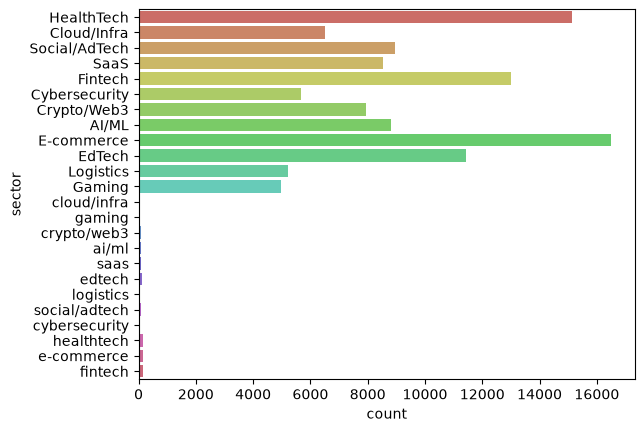

In [212]:
sns.countplot(y='sector',data=df, palette='hls')

there are repeated sector due to case senstivity

In [213]:
df['sector'].value_counts()

sector
E-commerce       16491
HealthTech       15125
Fintech          13008
EdTech           11414
Social/AdTech     8938
AI/ML             8803
SaaS              8522
Crypto/Web3       7954
Cloud/Infra       6502
Cybersecurity     5677
Logistics         5231
Gaming            4985
e-commerce         172
healthtech         145
fintech            139
edtech             125
social/adtech       99
saas                88
crypto/web3         87
ai/ml               87
cloud/infra         60
gaming              57
logistics           49
cybersecurity       49
Name: count, dtype: int64

In [214]:
df['sector']=df['sector'].str.upper()

C:\Users\syed altamash\AppData\Local\Temp\ipykernel_15328\3788966777.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='sector',data=df, palette='hls')


<Axes: xlabel='count', ylabel='sector'>

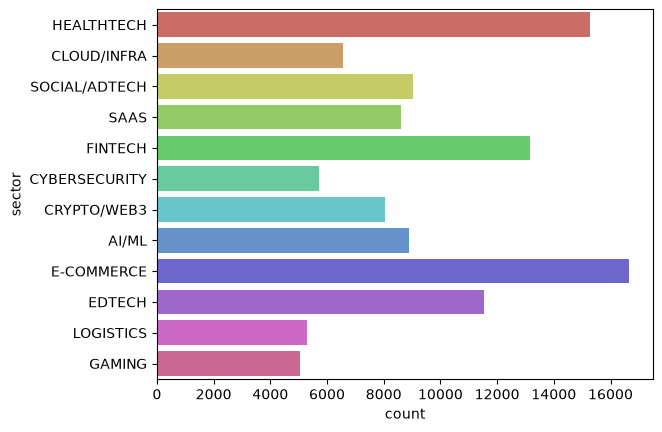

In [215]:
sns.countplot(y='sector',data=df, palette='hls')


In [216]:
df['company_name'].value_counts()

company_name
NexusShield                     3228
MeridianToken                   3173
RidgeFreight Labs               3084
SpireCloud                      3000
AetherAI Co                     2720
EchoFreight Systems             2630
BeaconStack Co                  2509
AnchorBuzz Labs                 2492
DriftGame Co                    2410
MeridianShield Labs             2373
OrbitNeural Technologies        2246
NovaFleet                       2203
FusionTrade                     2198
NexusCompute                    2195
AstraSuite                      2077
CobaltWealth                    2063
LumenArcade Technologies        2037
DriftSkill Inc                  1990
EchoCortex Co                   1926
PinnacleBlock                   1811
VertexBlock Inc                 1750
PinnacleLedger Labs             1740
QuantumBuzz Technologies        1738
NovaCare                        1701
TideFort                        1632
VertexCompute Inc               1620
BeaconPixel              

In [217]:
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

job_id: 113000 unique values
company_name: 898 unique values
company_type: 5 unique values
sector: 12 unique values
company_size_employees: 75225 unique values
hq_country: 13 unique values
job_role: 160 unique values
seniority_level: 6 unique values
years_experience_min: 21 unique values
years_experience_max: 21 unique values
required_tech_stack: 29271 unique values
primary_programming_language: 15 unique values
work_mode: 13 unique values
visa_sponsorship_offered: 8 unique values
job_location_country: 13 unique values
job_location_city: 41 unique values
salary_currency: 10 unique values
posting_date: 2638 unique values
application_deadline: 2843 unique values
date_position_filled: 2791 unique values
position_status: 4 unique values
number_of_applicants: 1652 unique values
number_of_interview_rounds: 8 unique values
offers_extended: 9 unique values
offers_accepted: 11 unique values
salary_min_usd: 4795 unique values
salary_max_usd: 4157 unique values
layoff_within_12_months_flag: 8 uni

In [218]:
df['salary_min_usd'] = df['salary_min_usd'].str.replace(r'[^\d.-]', '', regex=True)

df['salary_min_usd'] = pd.to_numeric(df['salary_min_usd'], errors='coerce')

In [219]:
df['salary_max_usd'] = df['salary_max_usd'].str.replace(r'[^\d.-]', '', regex=True)

df['salary_max_usd'] = pd.to_numeric(df['salary_max_usd'], errors='coerce')

In [220]:
df[['salary_max_usd','salary_min_usd']].describe()

,salary_max_usd,salary_min_usd
count,1.098450e+05,109845.000000
mean,1.417029e+05,114661.491857
std,9.163979e+04,57596.897636
min,-1.000000e+00,-1.000000
25%,9.190000e+04,75900.000000
50%,1.281000e+05,105400.000000
75%,1.774000e+05,145800.000000
max,3.552000e+06,531800.000000


In [221]:
df['job_role'].value_counts()   

job_role
Backend Engineer                  5939
Embedded Systems Engineer         5912
QA Engineer                       5854
Software Engineer                 5820
Frontend Engineer                 5786
Mobile Engineer (iOS)             5734
Full Stack Engineer               5726
Mobile Engineer (Android)         5691
DevOps Engineer                   3571
Infrastructure Engineer           3550
Cloud Engineer                    3520
Platform Engineer                 3508
Site Reliability Engineer         3508
Machine Learning Engineer         3094
Data Analyst                      3061
Analytics Engineer                2930
Data Scientist                    2917
Research Scientist                2884
Data Engineer                     2870
Product Owner                     2845
Product Manager                   2835
Technical Program Manager         2808
Associate Product Manager         2801
SOC Analyst                       2271
Security Engineer                 2258
Penetration Test

## analysis
- some job role are listed multiple times due to case senstivity

In [222]:
df['job_role']=df['job_role'].str.upper()

In [223]:

df['job_role'].value_counts()

job_role
BACKEND ENGINEER                  6022
EMBEDDED SYSTEMS ENGINEER         5986
QA ENGINEER                       5930
SOFTWARE ENGINEER                 5882
FRONTEND ENGINEER                 5865
MOBILE ENGINEER (IOS)             5814
FULL STACK ENGINEER               5786
MOBILE ENGINEER (ANDROID)         5778
DEVOPS ENGINEER                   3623
INFRASTRUCTURE ENGINEER           3602
CLOUD ENGINEER                    3558
PLATFORM ENGINEER                 3557
SITE RELIABILITY ENGINEER         3546
MACHINE LEARNING ENGINEER         3130
DATA ANALYST                      3096
ANALYTICS ENGINEER                2963
DATA SCIENTIST                    2949
RESEARCH SCIENTIST                2932
DATA ENGINEER                     2910
PRODUCT OWNER                     2881
PRODUCT MANAGER                   2871
ASSOCIATE PRODUCT MANAGER         2844
TECHNICAL PROGRAM MANAGER         2840
SOC ANALYST                       2297
SECURITY ENGINEER                 2283
PENETRATION TEST

## analysis 
- job_role reduced to 96 unique values from 160

In [224]:
df['work_mode'].value_counts()

work_mode
Hybrid            48423
Remote            31986
Onsite            26470
HYBRID             1487
hybrid             1333
remote              593
Work From Home      560
WFH                 556
REMOTE              548
ONSITE              472
onsite              463
In-office           461
On-site             455
Name: count, dtype: int64

## analysis
- same work_mode is listed multiple time due to case_senstivity

In [225]:
df['work_mode']=df['work_mode'].str.lower()

In [226]:
df['work_mode'].value_counts()

work_mode
hybrid            51243
remote            33127
onsite            27405
work from home      560
wfh                 556
in-office           461
on-site             455
Name: count, dtype: int64

In [227]:
df['work_mode']=df['work_mode'].str.replace('work from home','wfh')
df['work_mode']=df['work_mode'].str.replace('on-site','onsite')
df['work_mode'].value_counts()

work_mode
hybrid       51243
remote       33127
onsite       27860
wfh           1116
in-office      461
Name: count, dtype: int64

<Axes: xlabel='work_mode', ylabel='count'>

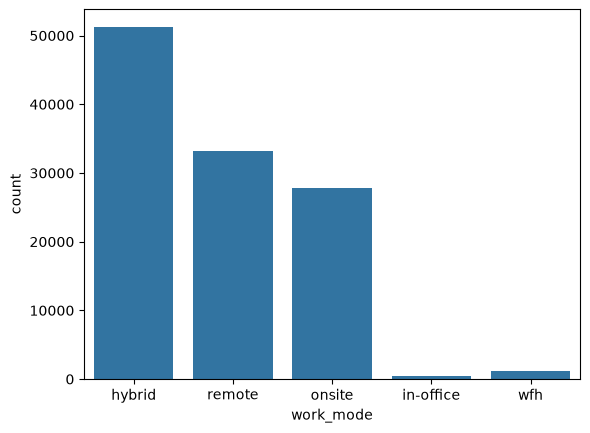

In [228]:
sns.countplot(x='work_mode', data=df)

 # Analysis
 - most of the jobs offer hybrid,remote working oppurtunity

In [229]:
df['visa_sponsorship_offered'].value_counts()

visa_sponsorship_offered
0        19625
False    19555
N        19553
No       19346
Yes       9001
True      8937
1         8897
Y         8893
Name: count, dtype: int64

- binary catogorical field having multiple inputs from true false value

In [230]:
df['visa_sponsorship_offered']=df['visa_sponsorship_offered'].replace({"False": 0,"No": 0,"N":0,"True": 1,"Yes": 1,"Y":1,"0":0,"1":1})

In [231]:
df['visa_sponsorship_offered'].value_counts()

visa_sponsorship_offered
0    78079
1    35728
Name: count, dtype: int64

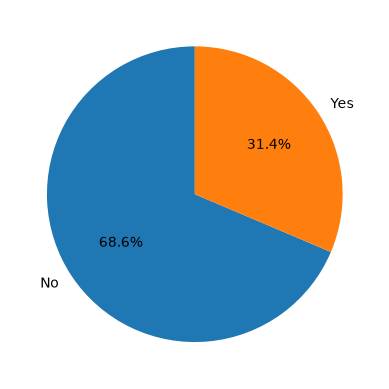

In [232]:
plot.pie(df['visa_sponsorship_offered'].value_counts(), labels=['No', 'Yes'], startangle=90,autopct='%1.1f%%')

In [233]:
df['layoff_within_12_months_flag'].value_counts()

layoff_within_12_months_flag
N        24905
0        24736
False    24717
No       24526
Y         3785
Yes       3759
1         3734
True      3645
Name: count, dtype: int64

In [234]:
df['layoff_within_12_months_flag']=df['layoff_within_12_months_flag'].replace({"False": 0,"No": 0,"N":0,"True": 1,"Yes": 1,"Y":1,"0":0,"1":1})

In [235]:
df['layoff_within_12_months_flag'].value_counts()

layoff_within_12_months_flag
0    98884
1    14923
Name: count, dtype: int64

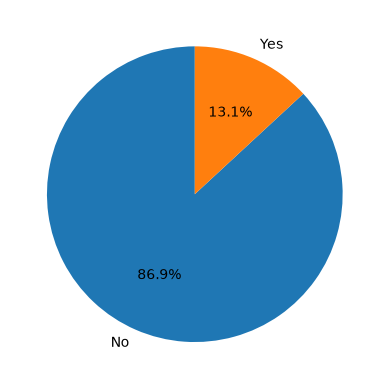

In [236]:
plot.pie(df['layoff_within_12_months_flag'].value_counts(), labels=['No', 'Yes'], autopct='%1.1f%%', startangle=90)

# bivariate analysis

<Axes: >

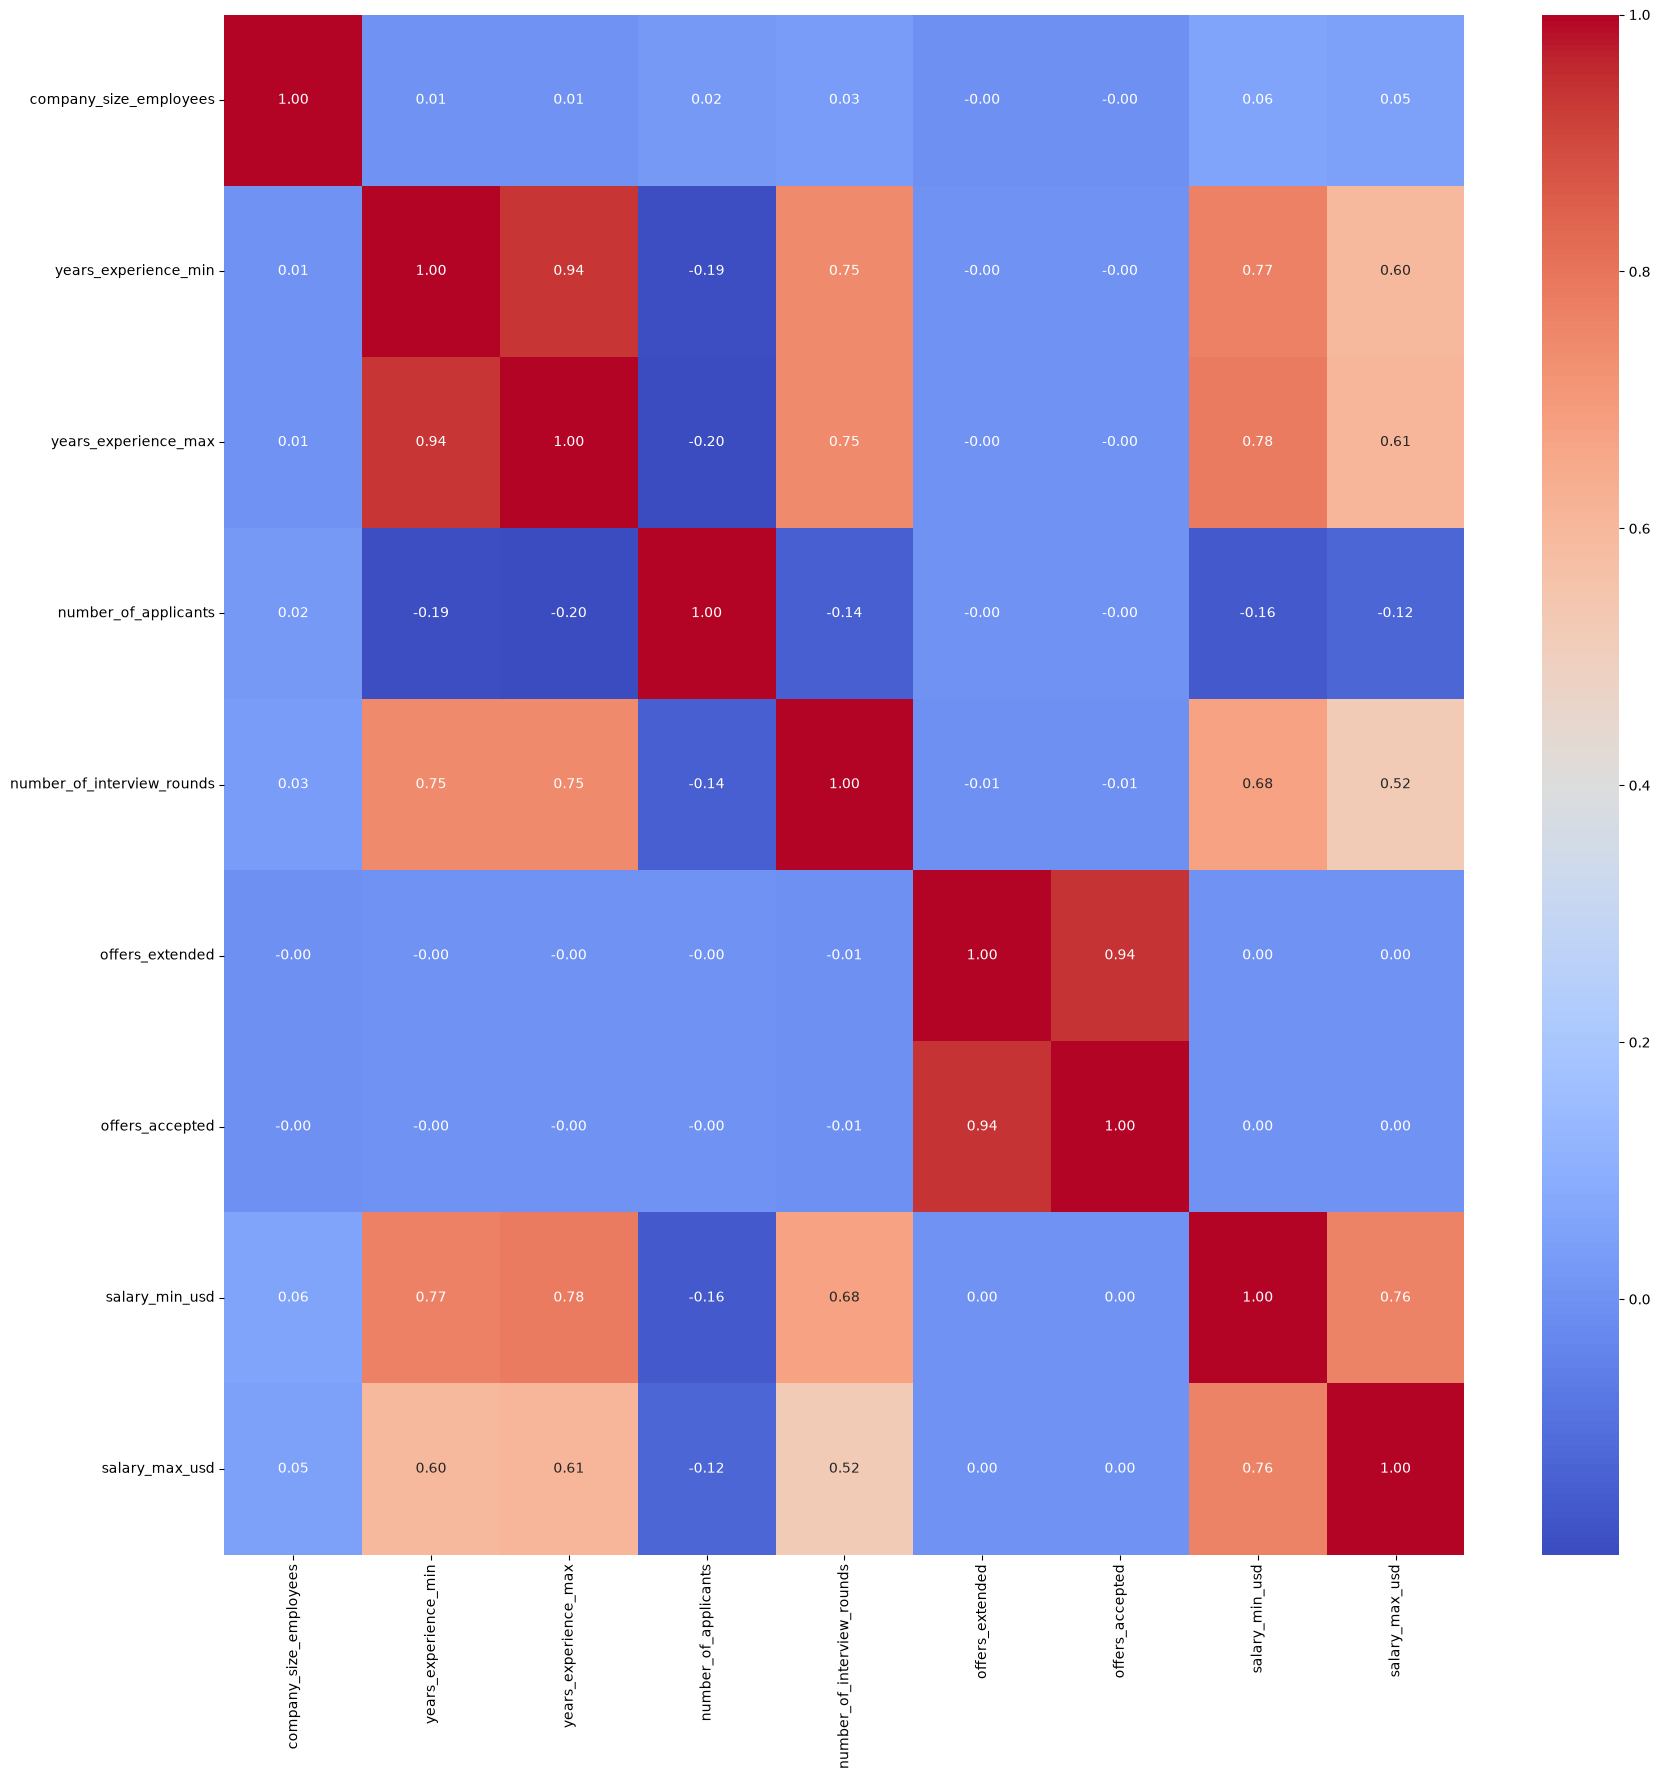

In [237]:
plot.figure(figsize=(20,20))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')

## relation analysis
- offers_extended and offers_accepted have 0.94 correlation index
- number_of_interview_rounds have corelation of 0.75 with years_experience_min,max
- years_experience_min and years_experience_max have 0.94 correlation index

<Axes: xlabel='offers_extended', ylabel='offers_accepted'>

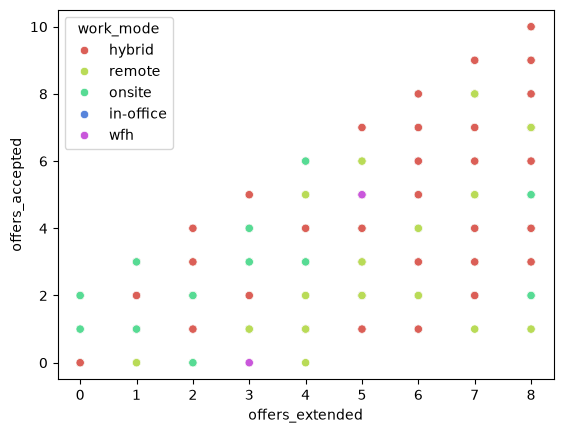

In [238]:
sns.scatterplot(x='offers_extended', y='offers_accepted', data=df, hue='work_mode', palette='hls')

## plot analysis
- offers_accepted exceeds offers_extended at some locations

In [239]:
(df['offers_accepted'] > df['offers_extended']).value_counts()

False    113216
True        591
Name: count, dtype: int64

In [240]:
df2 = df[df['offers_accepted'] > df['offers_extended']]
print(df2[['position_status', 'offers_extended', 'offers_accepted']].where(df2['offers_extended'] == 0).dropna().value_counts())

position_status  offers_extended  offers_accepted
Withdrawn        0.0              1.0                14
Cancelled        0.0              1.0                13
Withdrawn        0.0              2.0                11
Cancelled        0.0              2.0                 9
Name: count, dtype: int64


## analysis
- we can reduce offers_accepted to 0 where offers_extended==0

In [241]:
df.loc[df['offers_extended'] == 0, 'offers_accepted'] = 0

In [242]:
df2 = df[df['offers_accepted'] > df['offers_extended']]
print(df2[['position_status', 'offers_extended', 'offers_accepted']].value_counts())

position_status  offers_extended  offers_accepted
Filled           1.0              2.0                210
                                  3.0                199
Open             1.0              2.0                 28
                                  3.0                 14
Cancelled        1.0              3.0                  8
Filled           8.0              9.0                  7
                 7.0              8.0                  7
                 5.0              6.0                  6
                 2.0              3.0                  6
                 7.0              9.0                  5
                 3.0              5.0                  5
                 4.0              5.0                  4
Withdrawn        1.0              3.0                  4
                                  2.0                  4
Filled           2.0              4.0                  3
                 6.0              8.0                  3
Open             3.0              4.0 

# analysis
- since we dont know about job_vacancies,we cannot amend the data inconsistency
- there are chances that offer was cancelled/withdrawn after offers_extended or offers_accepted

In [243]:
df[['hq_country','job_location_country','salary_currency']].value_counts()

hq_country   job_location_country  salary_currency
USA          USA                   USD                31847
India        India                 INR                16572
UK           UK                    GBP                13310
Germany      Germany               EUR                 6153
Canada       Canada                CAD                 5336
Brazil       Brazil                BRL                 4984
Singapore    Singapore             SGD                 4935
France       France                EUR                 4312
Australia    Australia             AUD                 2901
UAE          UAE                   AED                 2713
Israel       Israel                ILS                 2625
Netherlands  Netherlands           EUR                 2215
Ireland      Ireland               EUR                 1768
USA          India                 INR                 1049
India        USA                   USD                  965
UK           USA                   USD           

In [244]:
print(df[df['posting_date'] > df['application_deadline']])

Empty DataFrame
Columns: [job_id, company_name, company_type, sector, company_size_employees, hq_country, job_role, seniority_level, years_experience_min, years_experience_max, required_tech_stack, primary_programming_language, work_mode, visa_sponsorship_offered, job_location_country, job_location_city, salary_currency, posting_date, application_deadline, date_position_filled, position_status, number_of_applicants, number_of_interview_rounds, offers_extended, offers_accepted, salary_min_usd, salary_max_usd, layoff_within_12_months_flag]
Index: []


### there is no inconsistency in posting and application_deadline dates

In [245]:
df['offer_accept_ratio'] = df['offers_accepted'] / df['offers_extended']

<Axes: xlabel='offer_accept_ratio', ylabel='Density'>

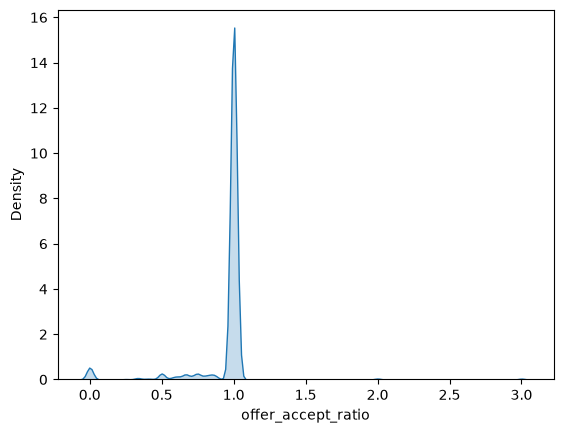

In [246]:
sns.kdeplot(df['offer_accept_ratio'].dropna(), fill=True)

# analysis
- Generally most of the offers were accepted

In [247]:
df[['hq_country','job_location_country','visa_sponsorship_offered','work_mode']].value_counts()

hq_country   job_location_country  visa_sponsorship_offered  work_mode
USA          USA                   0                         hybrid       7597
                                   1                         hybrid       6739
India        India                 0                         hybrid       6451
USA          USA                   0                         remote       5024
                                   1                         remote       4291
                                   0                         onsite       4204
India        India                 0                         remote       4030
USA          USA                   1                         onsite       3577
India        India                 0                         onsite       3429
UK           UK                    0                         hybrid       2966
                                   1                         hybrid       2929
Germany      Germany               0                        

In [248]:
print(df[df['years_experience_min'] > df['years_experience_max']])


           job_id  ... offer_accept_ratio
131     JOB031986  ...           1.000000
133     JOB089059  ...           1.000000
679     JOB101867  ...           1.000000
1943    JOB011486  ...           1.000000
2301    JOB101144  ...           0.750000
3599    JOB089178  ...           1.000000
3899    JOB109747  ...           1.000000
4032    JOB009601  ...           1.000000
4344    JOB043370  ...           1.000000
4457    JOB050190  ...           1.000000
4733    JOB001576  ...           1.000000
4819    JOB011274  ...           1.000000
5052    JOB029169  ...           1.000000
5093    JOB088592  ...                NaN
5186    JOB053704  ...           1.000000
5659    JOB066620  ...           1.000000
5856    JOB110702  ...           1.000000
5943    JOB089600  ...           3.000000
6612    JOB000387  ...           1.000000
6918    JOB023352  ...           1.000000
7021    JOB081416  ...           2.000000
7901    JOB013197  ...           0.833333
8811    JOB025130  ...           1

## analysis
- there are 315 rows where years_experience_min > years_experience_max
- high possibility that records got swapped while entry

therefore we can swap values

In [249]:
mask=df['years_experience_min'] > df['years_experience_max']
df.loc[mask, ['years_experience_min','years_experience_max']] = df.loc[mask, ['years_experience_max', 'years_experience_min']].values

<Axes: xlabel='company_size_employees', ylabel='company_type'>

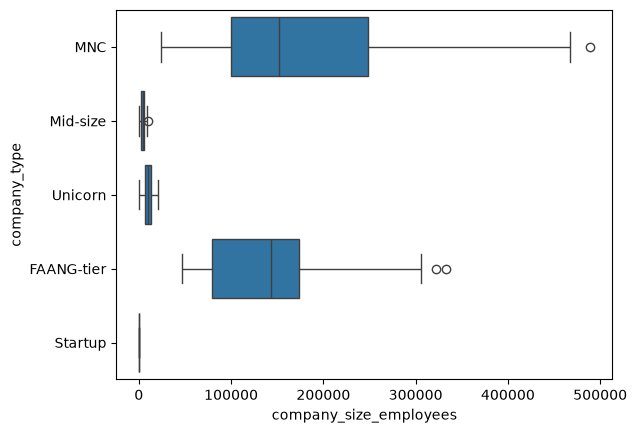

In [250]:
sns.boxplot(x='company_size_employees',y='company_type', data=df)

In [251]:
df['year']=pd.to_datetime(df['posting_date']).dt.year

<Axes: xlabel='year', ylabel='number_of_applicants'>

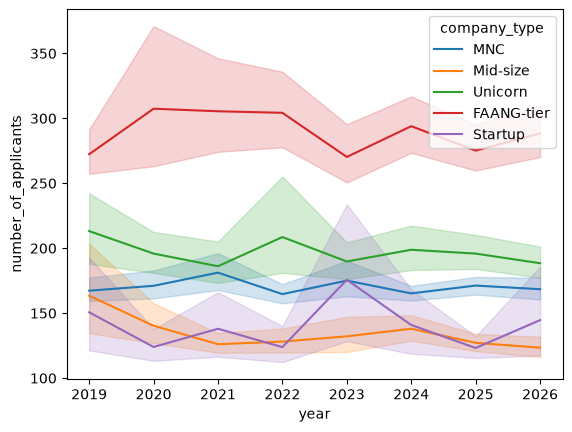

In [252]:
sns.lineplot(x='year', y='number_of_applicants', hue='company_type', data=df)

# Conclusions
- Most job postings were from the sector of Healthcare,E-commerce,Fintech
- There are 96 job roles listed across sector 
- hybrid and remote work_mode were prominent in job_postings across 2019-2026
- 31% of the total job postings sponsered visa of the applicants
- layoff within a year was saturated at approx 13%
- 

## Feature Engineering and encoding

In [253]:
df['salary_min_usd'] = df['salary_min_usd'].apply(lambda x: np.nan if pd.notna(x) and x < 0 else x)
df['salary_max_usd'] = df['salary_max_usd'].apply(lambda x: np.nan if pd.notna(x) and x < 0 else x)

In [254]:
df[df['salary_min_usd'] > df['salary_max_usd']]


,job_id,company_name,company_type,sector,company_size_employees,hq_country,job_role,seniority_level,years_experience_min,years_experience_max,required_tech_stack,primary_programming_language,work_mode,visa_sponsorship_offered,job_location_country,job_location_city,salary_currency,posting_date,application_deadline,date_position_filled,position_status,number_of_applicants,number_of_interview_rounds,offers_extended,offers_accepted,salary_min_usd,salary_max_usd,layoff_within_12_months_flag,offer_accept_ratio,year
7,JOB057551,EchoCortex Co,MNC,CYBERSECURITY,128882,USA,EMBEDDED SYSTEMS ENGINEER,Entry,0,4,"Python, C++",Kotlin,remote,0,USA,San Francisco,USD,2024-04-19,2024-05-25 00:00:00,2024-05-29,Filled,258.0,3.0,1.0,1.0,131100.0,103900.0,0,1.000000,2024
187,JOB080791,NexusShield,MNC,E-COMMERCE,335703,India,CLOUD ENGINEER,Senior,5,11,"Docker, AWS, Azure, GCP",Go,remote,0,USA,San Francisco,USD,2024-11-04,2024-12-07 00:00:00,2025-01-05,Filled,60.0,3.0,1.0,1.0,153900.0,132400.0,0,1.000000,2024
335,JOB102070,VertexCompute Inc,MNC,HEALTHTECH,100246,India,SOC ANALYST,Senior,6,10,"Splunk, Python, Burp Suite",Python,hybrid,0,India,Gurugram,INR,2025-01-10,2025-01-24 00:00:00,2025-03-06,Filled,168.0,4.0,1.0,1.0,182900.0,140800.0,0,1.000000,2025
702,JOB003325,OnyxSphere Inc,Mid-size,GAMING,6442,USA,EMBEDDED SYSTEMS ENGINEER,Mid,3,7,"Swift, Kotlin, Node.js, Go, C++",TypeScript,remote,0,USA,Austin,USD,2026-01-14,2026-03-10 00:00:00,2026-02-02,Filled,276.0,3.0,1.0,1.0,71800.0,65300.0,0,1.000000,2026
1231,JOB040177,TideCognition Technologies,Unicorn,CRYPTO/WEB3,15512,Australia,SECURITY ENGINEER,Senior,6,9,"Burp Suite, Wireshark, Python, Splunk",Go,hybrid,1,Australia,Melbourne,AUD,2023-02-06,2023-02-20 00:00:00,2023-02-23,Filled,52.0,5.0,1.0,1.0,208900.0,169200.0,1,1.000000,2023
1649,JOB074875,CobaltWealth,MNC,HEALTHTECH,148580,Germany,BACKEND ENGINEER,Lead,8,13,"Node.js, C++, Python, TypeScript",TBD,onsite,1,Germany,Hamburg,EUR,2023-01-07,2023-01-24 00:00:00,2023-03-10,Filled,40.0,5.0,1.0,1.0,264100.0,220200.0,0,1.000000,2023
1788,JOB037816,RidgeFleet Labs,Unicorn,SOCIAL/ADTECH,6964,Singapore,ASSOCIATE PRODUCT MANAGER,Mid,3,4,"SQL, Notion, Jira, Figma",NaN,onsite,1,Singapore,Singapore,SGD,2023-03-21,2023-05-12 00:00:00,2023-04-23,Filled,212.0,3.0,1.0,1.0,129900.0,107300.0,0,1.000000,2023
1809,JOB016573,HelixVita Co,Mid-size,AI/ML,5147,Germany,BACKEND ENGINEER,Intern,0,2,"C++, Kotlin, TypeScript, Node.js",C++,onsite,0,USA,Austin,USD,2024-06-26,2024-07-23 00:00:00,2024-07-06,Filled,171.0,2.0,1.0,1.0,33600.0,26300.0,0,1.000000,2024
1820,JOB072214,CobaltWealth,MNC,HEALTHTECH,130095,Germany,MOBILE ENGINEER (ANDROID),Mid,3,5,"React, Go, C++, TypeScript, Kotlin",JavaScript,remote,0,Germany,NaN,EUR,2021-02-02,Rolling,2021-03-22,Filled,222.0,2.0,1.0,1.0,140500.0,115700.0,0,1.000000,2021
2091,JOB030952,FusionTrade,MNC,FINTECH,157317,UAE,MOBILE ENGINEER (ANDROID),Mid,1,6,"Swift, C++, React, Python",TypeScript,hybrid,0,UAE,Dubai,AED,2022-06-03,2022-07-22 00:00:00,2022-07-17,Filled,109.0,4.0,1.0,1.0,169900.0,144800.0,0,1.000000,2022


In [255]:
mask=df['salary_min_usd'] > df['salary_max_usd']
df.loc[mask, ['salary_min_usd','salary_max_usd']] = df.loc[mask, ['salary_max_usd', 'salary_min_usd']].values

In [256]:
df['salary_min_usd'] = df['salary_min_usd'].fillna(
    df.groupby(['company_type','job_role' ,'seniority_level','years_experience_min'])['salary_min_usd'].transform('median')).fillna(df['salary_min_usd'].median())

df['salary_max_usd'] = df['salary_max_usd'].fillna(
    df.groupby(['company_type','job_role' ,'seniority_level','years_experience_max'])['salary_max_usd'].transform('median')).fillna(df['salary_max_usd'].median())


<Axes: xlabel='company_type', ylabel='salary_min_usd'>

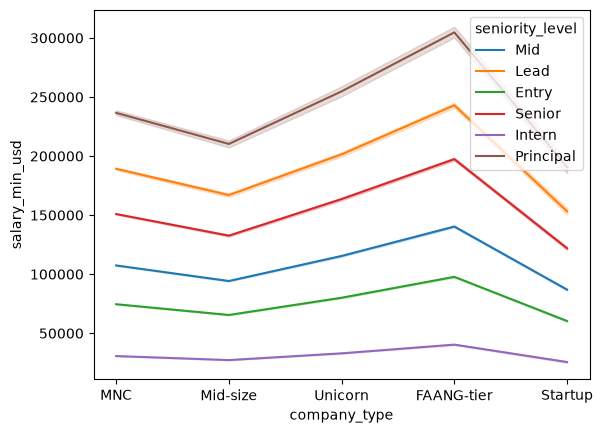

In [257]:
sns.lineplot(data=df,x='company_type',y='salary_min_usd',hue='seniority_level')

<Axes: xlabel='company_type', ylabel='salary_max_usd'>

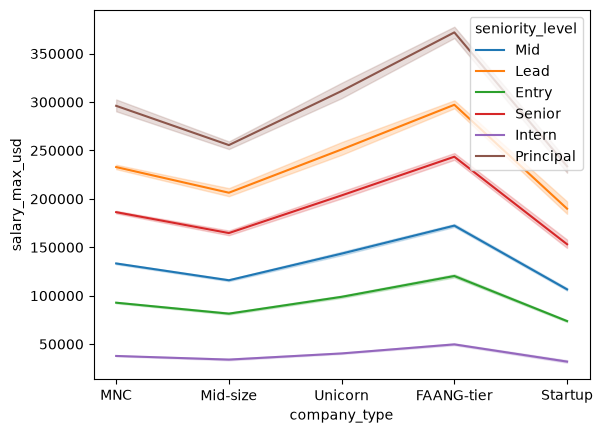

In [258]:
sns.lineplot(data=df,x='company_type',y='salary_max_usd',hue='seniority_level')

In [259]:
df['avg_salary']=(df['salary_min_usd']+df['salary_max_usd'])/2

<Axes: xlabel='sector', ylabel='avg_salary'>

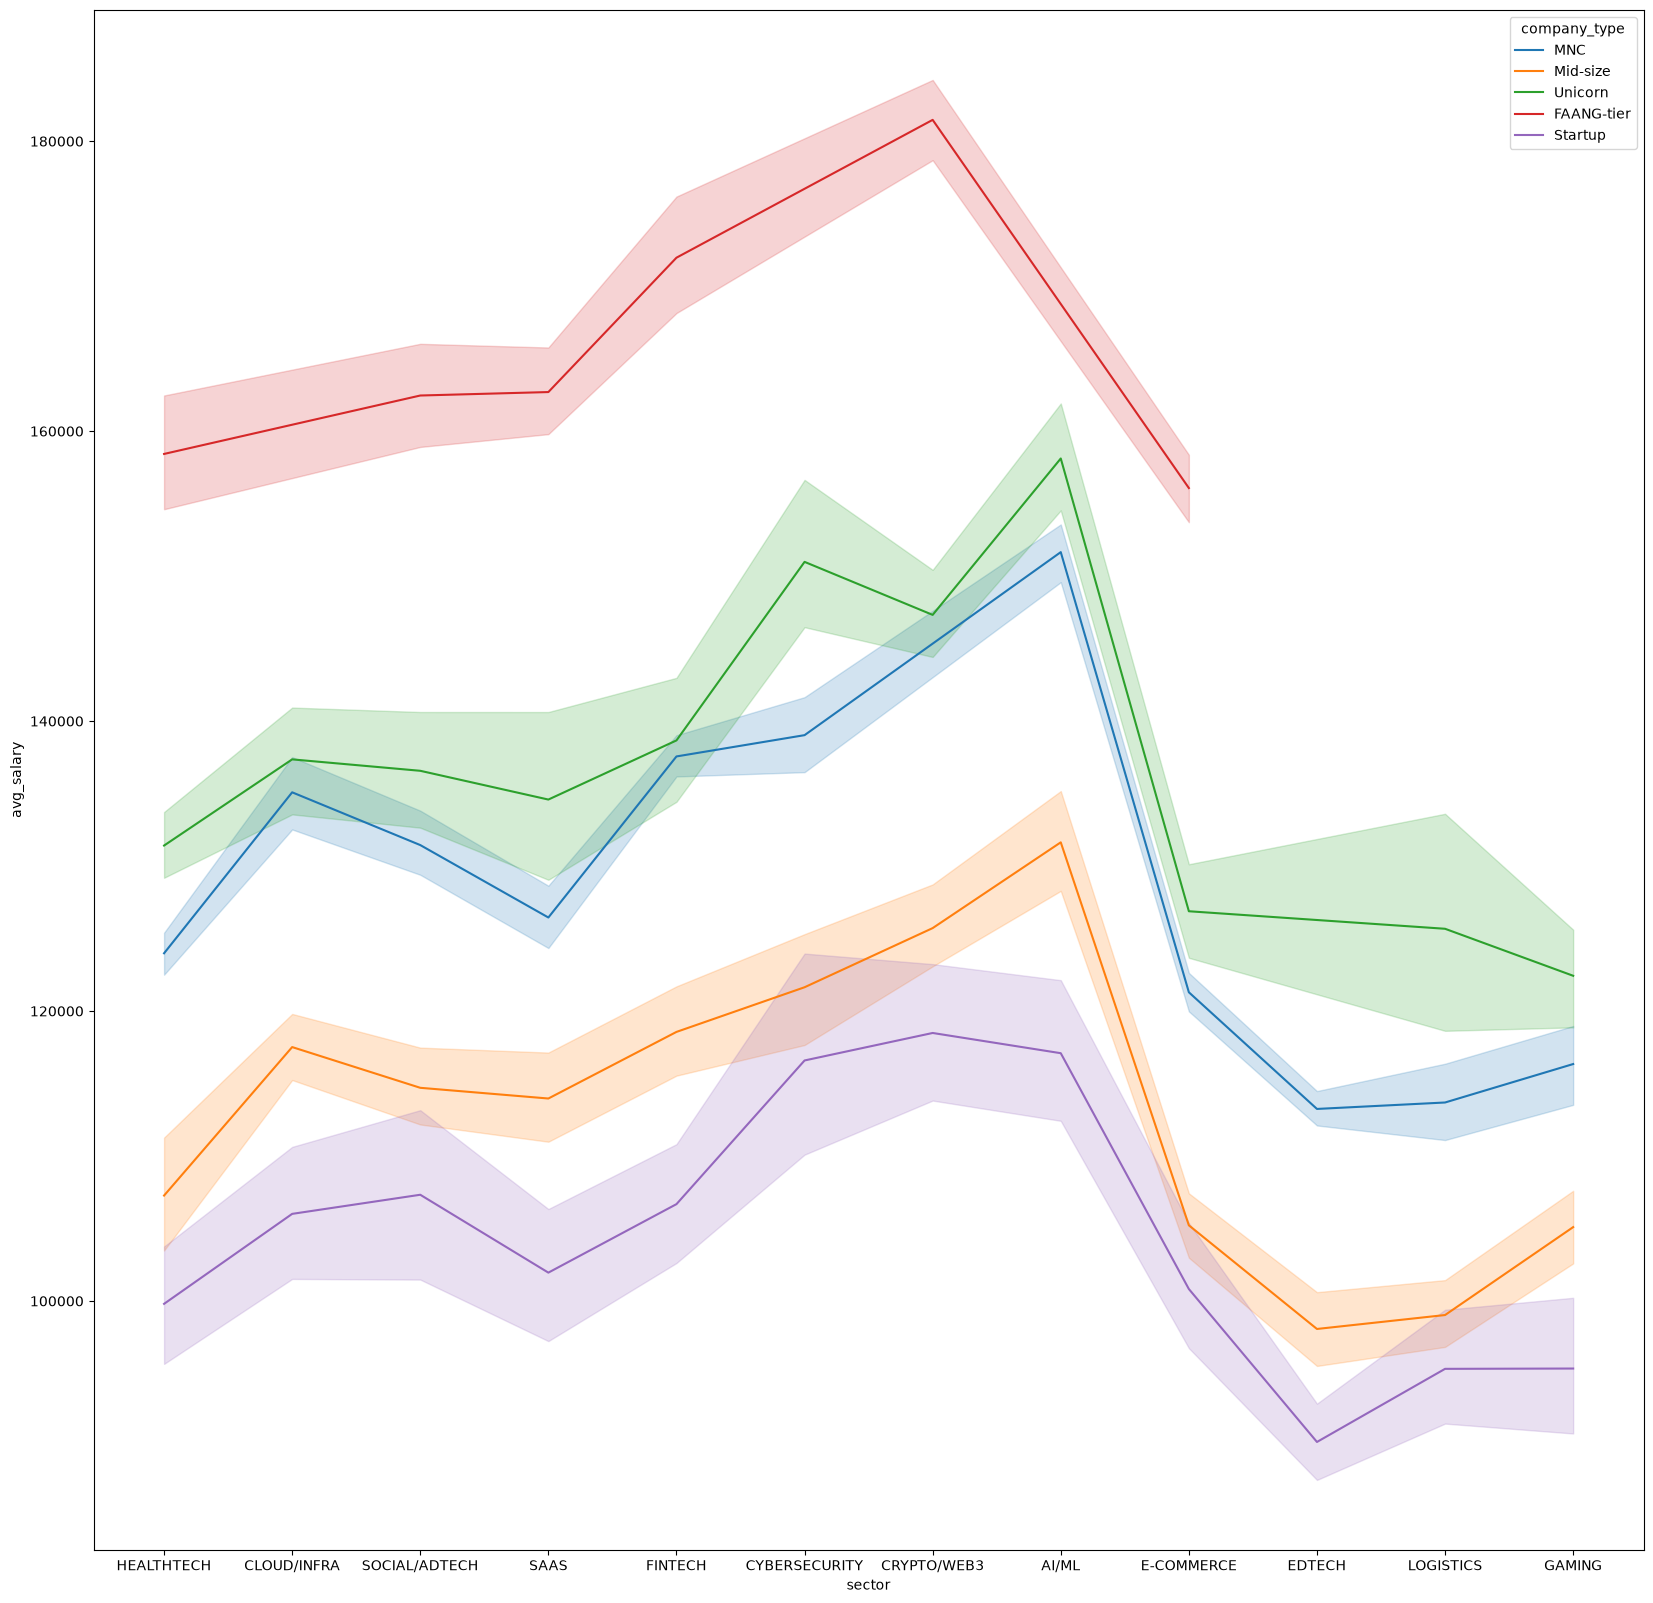

In [260]:
plot.figure(figsize=(20,20))
sns.lineplot(data=df,x='sector',y='avg_salary',hue='company_type')

<Axes: xlabel='hq_country', ylabel='avg_salary'>

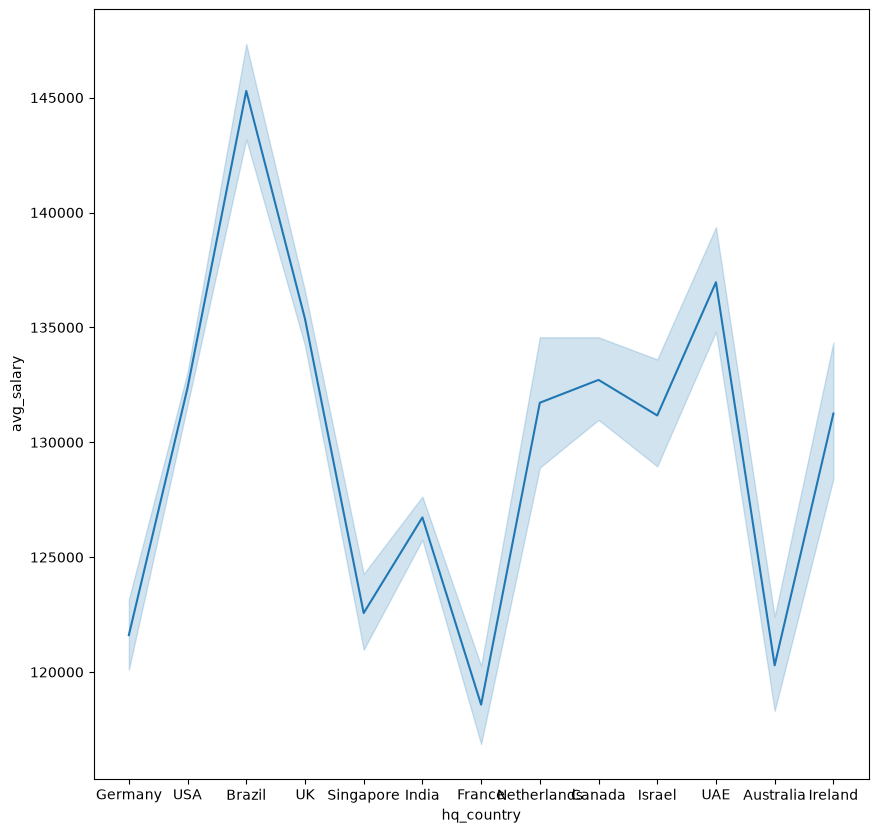

In [261]:
plot.figure(figsize=(10,10))
sns.lineplot(x='hq_country', y='avg_salary', data=df)


<Axes: xlabel='job_location_country', ylabel='avg_salary'>

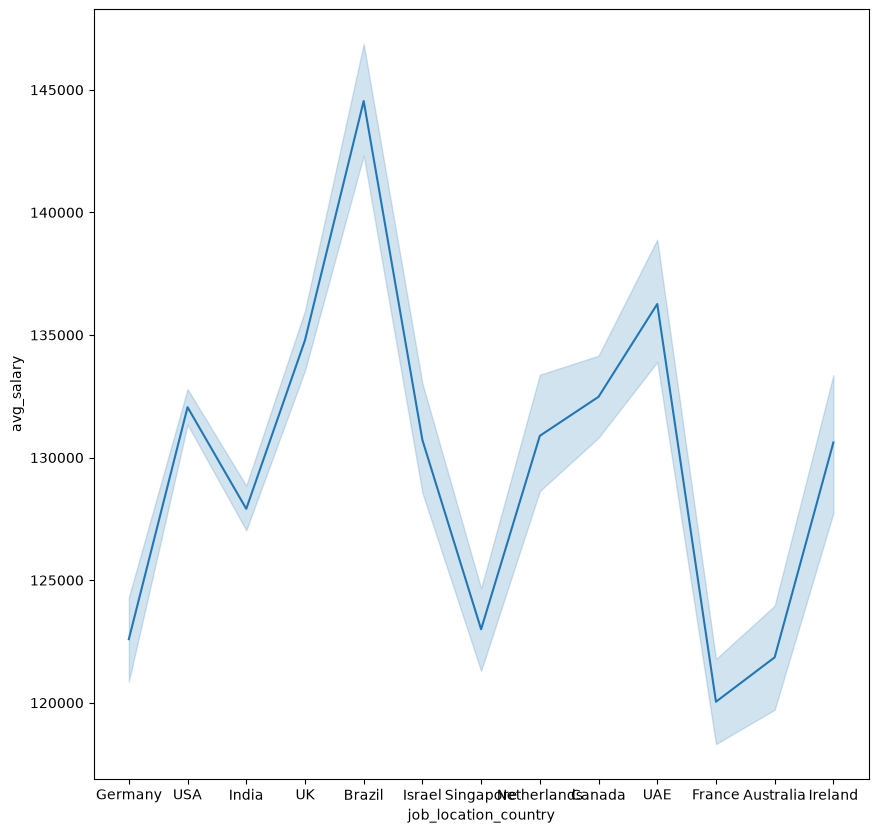

In [262]:
plot.figure(figsize=(10,10))
sns.lineplot(x='job_location_country', y='avg_salary', data=df)

In [263]:
df['avg_salary'].info()

<class 'pandas.Series'>
Index: 113807 entries, 0 to 114999
Series name: avg_salary
Non-Null Count   Dtype  
--------------   -----  
113807 non-null  float64
dtypes: float64(1)
memory usage: 1.7 MB


<Axes: xlabel='company_type', ylabel='avg_salary'>

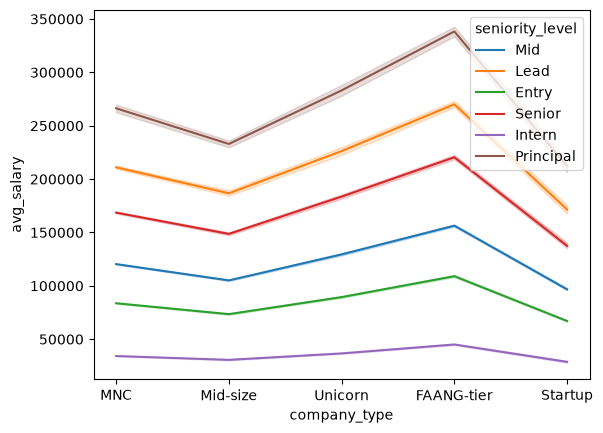

In [264]:
sns.lineplot(data=df,x='company_type',y='avg_salary',hue='seniority_level')

In [265]:
from sklearn.preprocessing import OrdinalEncoder

seniority = ['Intern','Entry','Mid','Senior','Lead','Principal']
company = ['Startup','Mid-size','MNC','Unicorn','FAANG-tier']

ordinal_encoder = OrdinalEncoder(categories=[seniority,company], handle_unknown='use_encoded_value', unknown_value=-1)

df[['seniority_Ordinal','company_ordinal']] = ordinal_encoder.fit_transform(df[['seniority_level','company_type']])

display(df[['seniority_level', 'seniority_Ordinal','company_ordinal','company_type']].head())

,seniority_level,seniority_Ordinal,company_ordinal,company_type
0,Mid,2.0,2.0,MNC
1,Mid,2.0,1.0,Mid-size
2,Lead,4.0,2.0,MNC
3,Entry,1.0,3.0,Unicorn
4,Senior,3.0,2.0,MNC


In [266]:
df['number_of_interview_rounds'].value_counts()

number_of_interview_rounds
3.0    31748
4.0    25072
2.0    23625
5.0    14002
1.0    10758
6.0     5976
7.0     1958
8.0      234
Name: count, dtype: int64

In [267]:
df['number_of_interview_rounds'].groupby(df['seniority_level']).value_counts()

seniority_level  number_of_interview_rounds
Entry            2.0                            9424
                 3.0                            9356
                 1.0                            8132
                 4.0                            1301
Intern           2.0                            3086
                 3.0                            2971
                 1.0                            2626
                 4.0                             435
Lead             6.0                            3451
                 5.0                            3416
                 4.0                            2978
                 7.0                             483
Mid              4.0                           12863
                 3.0                           12835
                 2.0                           11115
                 5.0                            1715
Principal        6.0                            1476
                 7.0                            1475
  

In [268]:
df['number_of_interview_rounds']=df['number_of_interview_rounds'].fillna(df.groupby('seniority_level')['number_of_interview_rounds'].transform(lambda x: x.mode()[0]))

In [269]:
from sklearn.model_selection import train_test_split
X = df[['seniority_Ordinal','company_ordinal','years_experience_min','years_experience_max']]
y = df['avg_salary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")


Shape of X_train: (91045, 4)
Shape of X_test: (22762, 4)
Shape of y_train: (91045,)
Shape of y_test: (22762,)


In [270]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[41480.27,15917.09, 491.04, 660.08]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['seniority_Ordinal','company_ordinal','years_experience_min', 'years_experience_max']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4060
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(4)


In [271]:
y_pred=lr.predict(X_test)

In [272]:
from sklearn.metrics import mean_absolute_error,r2_score,mean_squared_error,root_mean_squared_error

eval=[mean_absolute_error,mean_squared_error,root_mean_squared_error,r2_score]
for i in eval:
    print(i(y_test,y_pred))


22846.15059511316
1778486037.2104566
42172.100222901594
0.644588630765452


## adding

In [273]:
from sklearn.model_selection import train_test_split
X = df[['seniority_Ordinal','company_ordinal','years_experience_min','years_experience_max','number_of_interview_rounds']]
y = df['avg_salary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (91045, 5)
Shape of X_test: (22762, 5)
Shape of y_train: (91045,)
Shape of y_test: (22762,)


In [274]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[41128.69,15754.58, 415.76, 641.57, 675.88]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](5,)","['seniority_Ordinal','company_ordinal','years_experience_min', 'years_experience_max','number_of_interview_rounds']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,3252
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(5)


In [275]:
y_pred=lr.predict(X_test)
from sklearn.metrics import mean_absolute_error,r2_score,mean_squared_error,root_mean_squared_error

eval=[mean_absolute_error,mean_squared_error,root_mean_squared_error,r2_score]
for i in eval:
    print(i(y_test,y_pred))


22845.587900853807
1778912626.6317868
42177.157640502366
0.6445033814426213


In [276]:
mode_dummies = pd.get_dummies(df[['sector','hq_country']], prefix=('sector_','hq_'))

df = pd.concat([df, mode_dummies], axis=1)

display(df.head())

,job_id,company_name,company_type,sector,company_size_employees,hq_country,job_role,seniority_level,years_experience_min,years_experience_max,required_tech_stack,primary_programming_language,work_mode,visa_sponsorship_offered,job_location_country,job_location_city,salary_currency,posting_date,application_deadline,date_position_filled,position_status,number_of_applicants,number_of_interview_rounds,offers_extended,offers_accepted,salary_min_usd,salary_max_usd,layoff_within_12_months_flag,offer_accept_ratio,year,avg_salary,seniority_Ordinal,company_ordinal,sector__AI/ML,sector__CLOUD/INFRA,sector__CRYPTO/WEB3,sector__CYBERSECURITY,sector__E-COMMERCE,sector__EDTECH,sector__FINTECH,sector__GAMING,sector__HEALTHTECH,sector__LOGISTICS,sector__SAAS,sector__SOCIAL/ADTECH,hq__Australia,hq__Brazil,hq__Canada,hq__France,hq__Germany,hq__India,hq__Ireland,hq__Israel,hq__Netherlands,hq__Singapore,hq__UAE,hq__UK,hq__USA
0,JOB041385,CobaltWealth,MNC,HEALTHTECH,146085,Germany,SOC ANALYST,Mid,3,5,"AWS Security Hub, Burp Suite, Splunk",Go,hybrid,0,Germany,Munich,EUR,2023-09-21,2023-11-12 00:00:00,2023-11-20,Filled,98.0,4.0,5.0,5.0,107100.0,128700.0,0,1.000000,2023,117900.0,2.0,2.0,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False
1,JOB018462,DriftLearn,Mid-size,CLOUD/INFRA,5882,USA,MOBILE ENGINEER (IOS),Mid,1,4,"C++, TypeScript, Python, Kotlin",Python,remote,0,USA,NaN,USD,2025-05-11,2025-06-29 00:00:00,NaN,Open,134.0,2.0,1.0,0.0,90450.0,113700.0,0,0.000000,2025,102075.0,2.0,1.0,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
2,JOB110011,AnchorBuzz Labs,MNC,HEALTHTECH,186507,USA,QA ENGINEER,Lead,7,15,"Swift, C++, Kotlin, Python",Go,hybrid,1,USA,San Francisco,USD,2025-12-01,2026-01-24 00:00:00,2026-02-08,Filled,36.0,4.0,1.0,1.0,238800.0,274700.0,0,1.000000,2025,256750.0,4.0,2.0,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
3,JOB073462,KiteSphere,Unicorn,HEALTHTECH,10930,Brazil,RESEARCH SCIENTIST,Entry,1,4,"dbt, Spark, Python, Snowflake, Airflow",R,onsite,0,Germany,Frankfurt,EUR,2020-11-21,2020-12-09 00:00:00,2020-12-21,Filled,300.0,1.0,6.0,5.0,96300.0,104000.0,1,0.833333,2020,100150.0,1.0,3.0,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False
4,JOB051683,AetherNode Co,MNC,SOCIAL/ADTECH,42510,USA,PRODUCT MANAGER,Senior,6,9,"Amplitude, Jira, SQL, Notion, Figma",NaN,hybrid,0,India,Pune,INR,2025-07-03,2025-07-19 00:00:00,2025-09-15,Filled,43.0,3.0,1.0,1.0,186800.0,245400.0,1,1.000000,2025,216100.0,3.0,2.0,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True


In [277]:
from sklearn.model_selection import train_test_split
X = df[['seniority_Ordinal','company_ordinal','years_experience_min','years_experience_max','number_of_interview_rounds','company_size_employees']]
X = pd.concat([X,mode_dummies],axis=1)
y = df['avg_salary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (91045, 31)
Shape of X_test: (22762, 31)
Shape of y_train: (91045,)
Shape of y_test: (22762,)


In [278]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](31,)","[41339.53,14383.02, 433.53,..., -750.7 , 1869.55, 980.76]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](31,)","['seniority_Ordinal','company_ordinal','years_experience_min',..., 'hq__UAE','hq__UK','hq__USA']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,5080
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,31
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(29)


In [279]:
y_pred=lr.predict(X_test)
from sklearn.metrics import mean_absolute_error,r2_score,mean_squared_error,root_mean_squared_error

eval=[mean_absolute_error,mean_squared_error,root_mean_squared_error,r2_score]
for i in eval:
    print(i(y_test,y_pred))

21471.91153626652
1657594436.3776875
40713.56575366112
0.6687475212385665


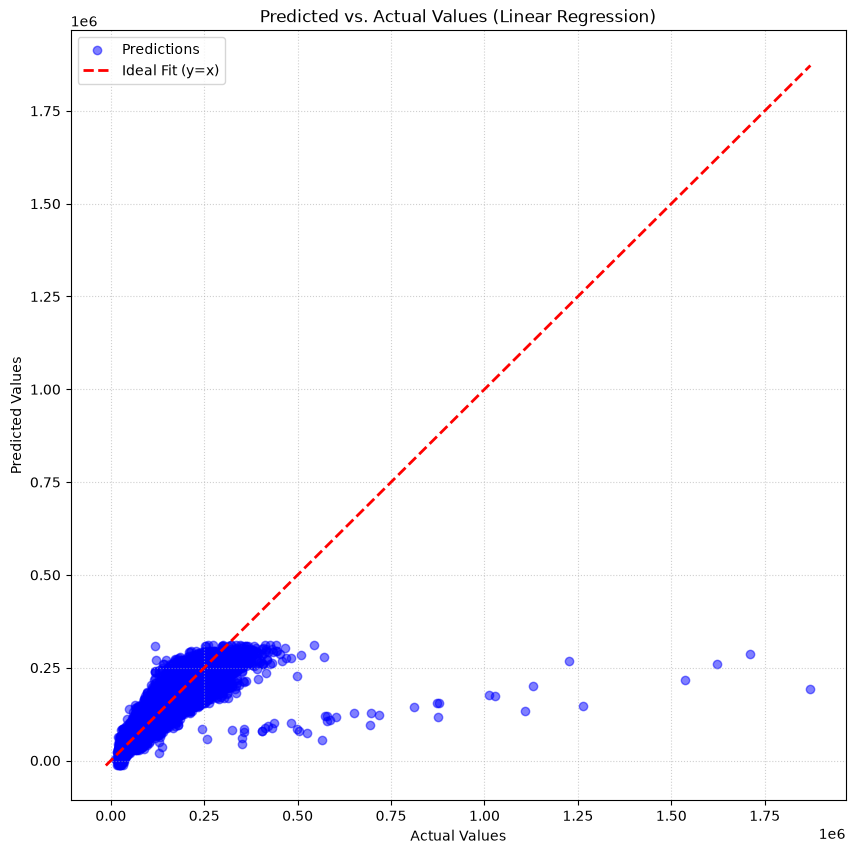

In [280]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Create the scatter plot
plt.figure(figsize=(10, 10))
plt.scatter(y_test, y_pred, color='blue', alpha=0.5, label='Predictions')

# 2. Add the ideal 45-degree reference line (Actual = Predicted)
min_val = min(min(y_test), min(y_pred))
max_val = max(max(y_test), max(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Ideal Fit (y=x)')

# 3. Add labels and styling
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Predicted vs. Actual Values (Linear Regression)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

# 4. Show the plot
plt.show()

## model got better

# predicting layoffs


<Axes: xlabel='company_type', ylabel='count'>

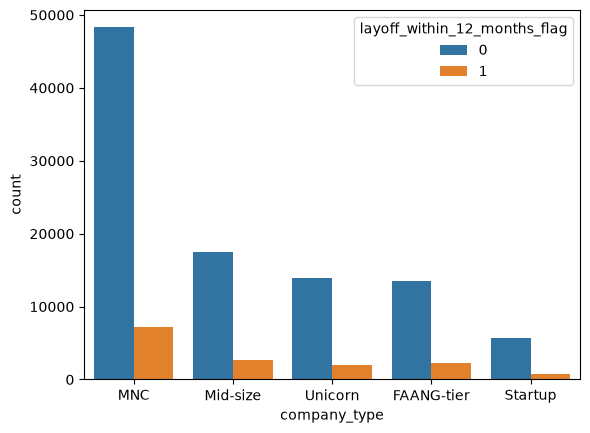

In [281]:
sns.countplot(data=df,x='company_type',hue='layoff_within_12_months_flag')

<Axes: xlabel='layoff_within_12_months_flag', ylabel='company_type'>

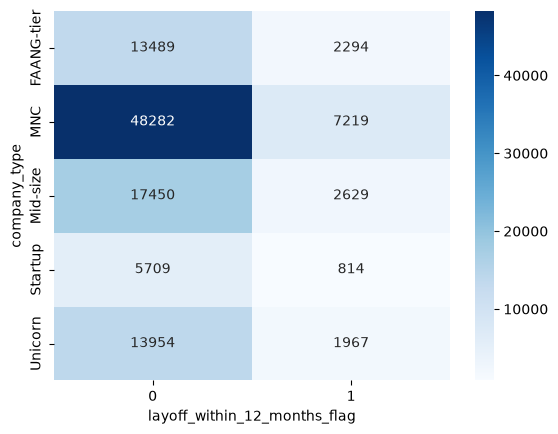

In [282]:
contingency_table = pd.crosstab(df['company_type'], df['layoff_within_12_months_flag'])
sns.heatmap(contingency_table, annot=True, cmap='Blues', fmt='d')

<Axes: xlabel='sector', ylabel='count'>

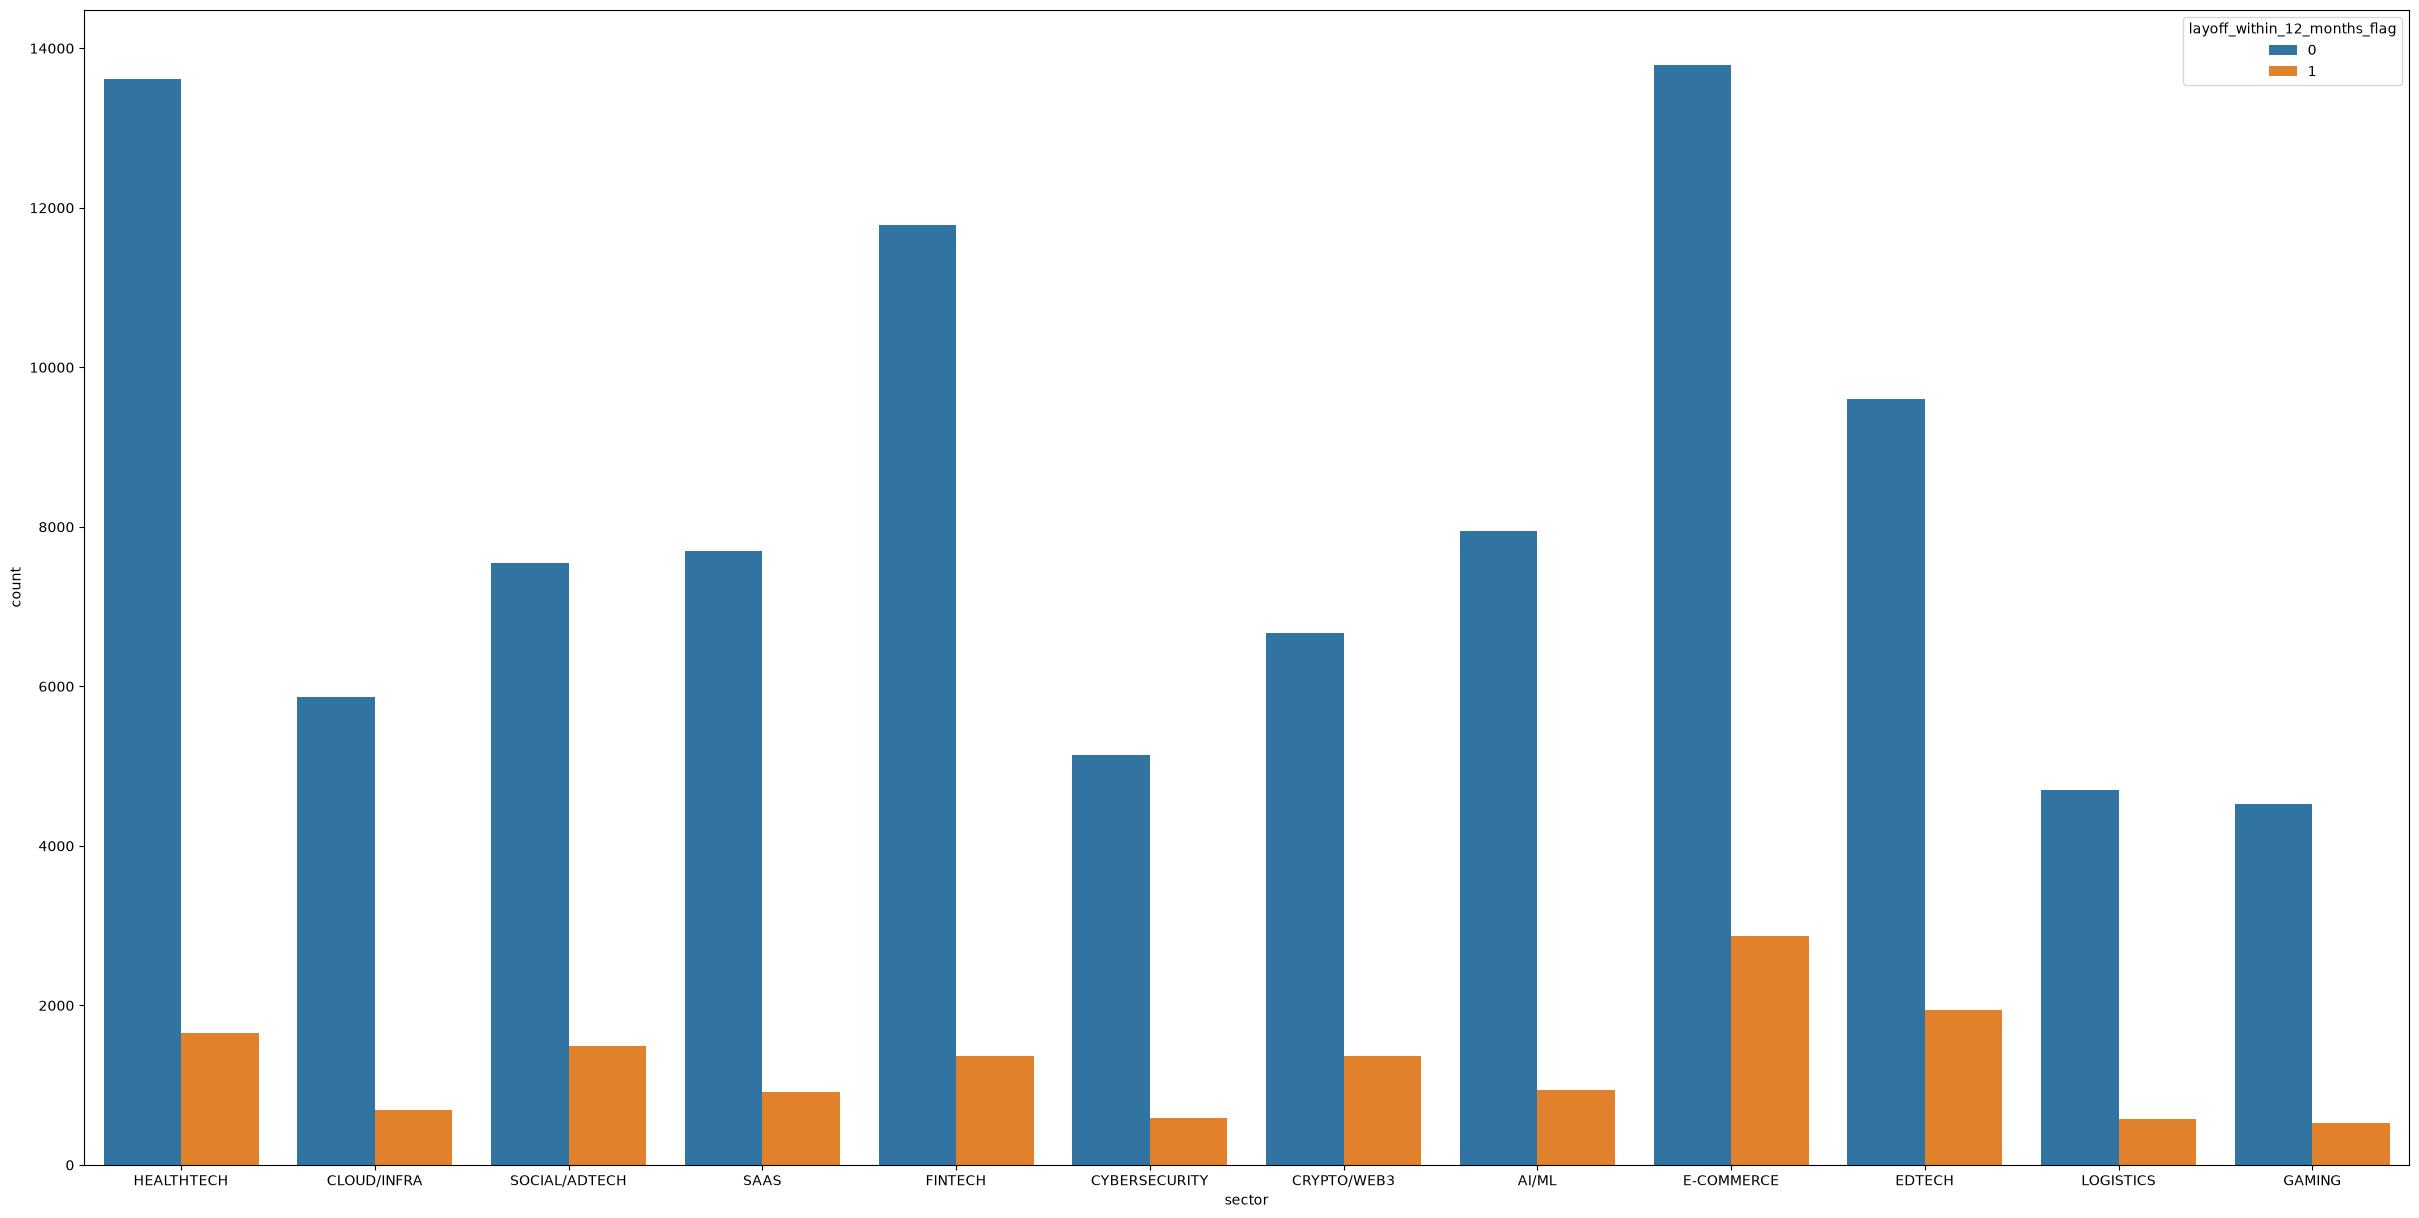

In [283]:
plot.figure(figsize=(30,15))
sns.countplot(data=df,x='sector',hue='layoff_within_12_months_flag')

<Axes: xlabel='year', ylabel='count'>

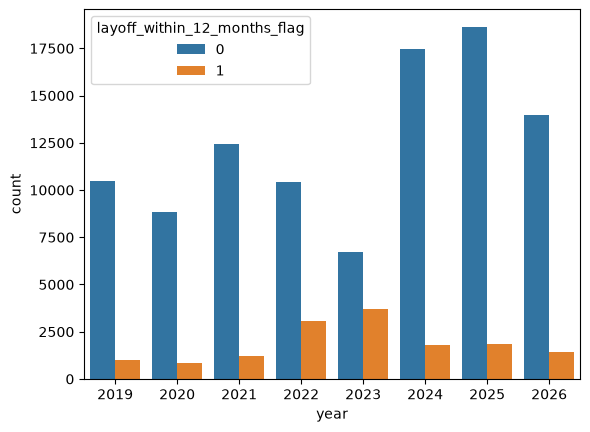

In [284]:
sns.countplot(data=df,x='year',hue='layoff_within_12_months_flag')

In [285]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X = df[['seniority_Ordinal','company_ordinal','years_experience_min','years_experience_max','number_of_interview_rounds','company_size_employees','year']]
X = pd.concat([X,mode_dummies],axis=1)
y = df['layoff_within_12_months_flag']
y=y.astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of X_train_scaled: {X_train_scaled.shape}")
print(f"Shape of X_test_scaled: {X_test_scaled.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (91045, 32)
Shape of X_test: (22762, 32)
Shape of X_train_scaled: (91045, 32)
Shape of X_test_scaled: (22762, 32)
Shape of y_train: (91045,)
Shape of y_test: (22762,)


In [286]:
class_counts = y.value_counts()
print("Raw Class Counts:")
print(class_counts)
class_percentages = y.value_counts(normalize=True) * 100
print("\nClass Percentages (%):")
print(class_percentages)

Raw Class Counts:
layoff_within_12_months_flag
0    98884
1    14923
Name: count, dtype: int64

Class Percentages (%):
layoff_within_12_months_flag
0    86.88745
1    13.11255
Name: proportion, dtype: float64


## the dataset is moderately imbalanced

# logistic Regression

In [287]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

model = LogisticRegression(class_weight='balanced',random_state=42)

model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 60.84%

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.62      0.73     19777
           1       0.17      0.51      0.25      2985

    accuracy                           0.61     22762
   macro avg       0.53      0.57      0.49     22762
weighted avg       0.80      0.61      0.67     22762



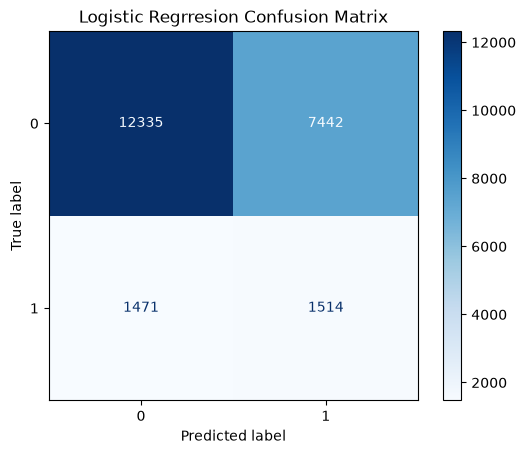

In [288]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm= confusion_matrix(y_test,y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Logistic Regrresion Confusion Matrix')
plt.show()

## intitution
- sigmoid function = 1/(1+e^(-z))
- log loss cost function = -ylog(y)-(1-y)log(1-y)


# Decision Tree Classifier

In [289]:
from sklearn.metrics import accuracy_score, classification_report
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42, class_weight="balanced")

model.fit(X_train, y_train)

y_pred_dt = model.predict(X_test)

# 4. Evaluate the model
accuracy_dt = accuracy_score(y_test, y_pred_dt)
print(f"Decision Tree Accuracy: {accuracy_dt * 100:.2f}%\n")

print("Classification Report:")
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 79.40%

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.88      0.88     19777
           1       0.21      0.21      0.21      2985

    accuracy                           0.79     22762
   macro avg       0.55      0.55      0.55     22762
weighted avg       0.79      0.79      0.79     22762



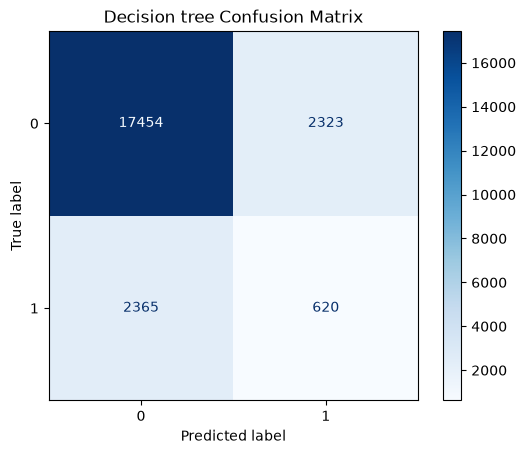

In [290]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm= confusion_matrix(y_test,y_pred_dt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Decision tree Confusion Matrix')
plt.show()

# summary
-  default splitting criterion used is gini impurity

# SVM

In [291]:
from sklearn.metrics import accuracy_score, classification_report
from sklearn.svm import LinearSVC

model_svm_lin = LinearSVC( C=1.0, class_weight="balanced", random_state=42)

model_svm_lin.fit(X_train_scaled, y_train)

y_pred_svm = model_svm_lin.predict(X_test_scaled)

accuracy_svm = accuracy_score(y_test, y_pred_svm)
print(f"SVM Accuracy: {accuracy_svm * 100:.2f}%\n")

print("Classification Report:")
print(classification_report(y_test, y_pred_svm))

SVM Accuracy: 60.84%

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.62      0.73     19777
           1       0.17      0.51      0.25      2985

    accuracy                           0.61     22762
   macro avg       0.53      0.57      0.49     22762
weighted avg       0.80      0.61      0.67     22762



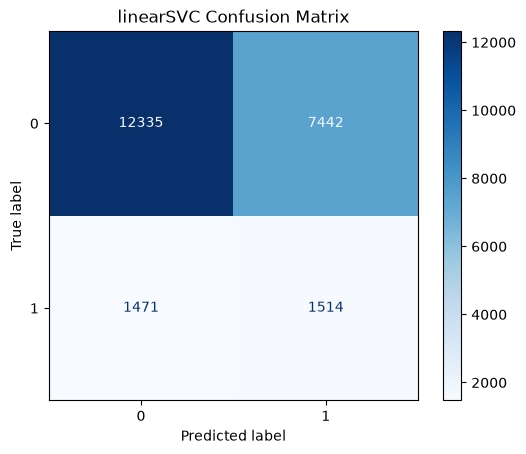

In [292]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm= confusion_matrix(y_test,y_pred_svm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('linearSVC Confusion Matrix')
plt.show()

# Comparison

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
predictions = {
    "Logistic Regression": y_pred,
    "Decision Tree": y_pred_dt,
    "SVM (Linear)": y_pred_svm,
}

results = []

for name, y_pred in predictions.items():
  results.append({
      "Model": name,
      "Accuracy": accuracy_score(y_test, y_pred),
      "Precision": precision_score(y_test, y_pred, average="weighted"),
      "Recall": recall_score(y_test, y_pred, average="weighted"),
      "F1-Score": f1_score(y_test, y_pred, average="weighted"),
  })

summary_df = pd.DataFrame(results)
summary_df.set_index("Model", inplace=True)
summary_df = summary_df.round(4)

summary_df

,Accuracy,Precision,Recall,F1-Score
Model,,,,
Logistic Regression,0.6084,0.7985,0.6084,0.6715
Decision Tree,0.7940,0.7928,0.7940,0.7934
SVM (Linear),0.6084,0.7985,0.6084,0.6715
